In [1]:
import pandas as pd

crop = pd.read_csv("crop_production.csv")

crop["Yield"] = crop["Production"] / crop["Area"]
crop = crop.dropna()

crop = crop[["State_Name", "District_Name", "Crop_Year", "Season", "Crop", "Yield"]]
crop.columns = ["State", "District", "Year", "Season", "Crop", "Yield"]


In [2]:
rain = pd.read_csv("district wise rainfall normal.csv")

rain = rain[["STATE_UT_NAME", "DISTRICT", "ANNUAL"]]
rain.columns = ["State", "District", "Annual_Rainfall"]


In [10]:
print("LAST 10 ROWS:")
print(market.tail(10))

LAST 10 ROWS:
             0                             1        2        3        4  \
17   Oil Seeds                      Soyabean  5328.00  5480.78  5543.39   
18   Oil Seeds                         Toria  4650.00  6650.00        -   
19      Pulses    Arhar(Tur/Red Gram)(Whole)  8000.00  7933.76  8050.28   
20      Pulses      Bengal Gram(Gram)(Whole)  5650.00  5375.14  5778.58   
21      Pulses  Black Gram(Urd Beans)(Whole)  7800.00  7059.99  7051.26   
22      Pulses      Green Gram(Moong)(Whole)  8768.00  6691.69  7459.30   
23      Pulses          Lentil(Masur)(Whole)  6700.00  6957.23  6956.72   
24  Vegetables                         Onion        -  1495.94  1543.37   
25  Vegetables                        Potato        -   775.10   791.39   
26  Vegetables                        Tomato        -  1483.08  1433.61   

          5         6         7         8  
17  5603.79   8036.52  13231.74  13723.30  
18        -      0.90         -         -  
19  8146.95   2798.88   4964

In [11]:
print("now it begins")

now it begins


In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor


In [13]:
crop = pd.read_csv("crop_production.csv")

# Remove invalid rows
crop = crop[crop["Area"] > 0]

# Compute yield
crop["Yield"] = crop["Production"] / crop["Area"]

crop = crop[[
    "State_Name", "District_Name", "Crop_Year",
    "Season", "Crop", "Yield"
]]

crop.columns = ["State", "District", "Year", "Season", "Crop", "Yield"]

# Normalize text
crop["State"] = crop["State"].str.upper().str.strip()
crop["District"] = crop["District"].str.upper().str.strip()
crop["Crop"] = crop["Crop"].str.strip().str.title()

crop.dropna(inplace=True)

print("Crop data:", crop.shape)


Crop data: (242361, 6)


In [15]:
rain = pd.read_csv("rainfall_district.csv")

rain = rain[["STATE_UT_NAME", "DISTRICT", "ANNUAL"]]
rain.columns = ["State", "District", "Annual_Rainfall"]

rain["State"] = rain["State"].str.upper().str.strip()
rain["District"] = rain["District"].str.upper().str.strip()

# Use STATE-level average rainfall (robust)
rain_state = rain.groupby("State", as_index=False)["Annual_Rainfall"].mean()

print("Rainfall data:", rain_state.shape)


Rainfall data: (35, 2)


In [17]:
market_raw = pd.read_csv(
    "Marketwise_Price_Arrival_09-02-2026_07-49-39_PM.csv",
    header=None
)

# Real data starts from row index 3
market = market_raw.iloc[3:].copy()

market = market.iloc[:, :6]
market.columns = [
    "Commodity_Group",
    "Crop",
    "MSP",
    "Price_D1",
    "Price_D2",
    "Price_D3"
]

# Clean numeric columns
for col in ["MSP", "Price_D1", "Price_D2", "Price_D3"]:
    market[col] = pd.to_numeric(market[col], errors="coerce")

# Average price
market["Market_Price"] = market[
    ["Price_D1", "Price_D2", "Price_D3"]
].mean(axis=1)

market = market[["Crop", "MSP", "Market_Price"]].dropna()

market["Crop"] = market["Crop"].str.strip().str.title()

# Map crop names to match crop dataset
crop_map = {
    "Paddy(Common)": "Rice",
    "Bajra(Pearl Millet/Cumbu)": "Bajra",
    "Jowar(Sorghum)": "Jowar",
    "Ragi(Finger Millet)": "Ragi",
    "Soyabean": "Soybean"
}

market["Crop"] = market["Crop"].replace(crop_map)

print("Market data:", market.shape)


Market data: (21, 3)


In [18]:
data = crop.merge(rain_state, on="State", how="left")
data = data.merge(market, on="Crop", how="left")

data["Profit"] = data["Yield"] * data["Market_Price"]

data = data.dropna()

print("FINAL MERGED DATA:", data.shape)
print(data.head())


FINAL MERGED DATA: (53079, 10)
                          State  District  Year       Season  Crop     Yield  \
2   ANDAMAN AND NICOBAR ISLANDS  NICOBARS  2000  Kharif       Rice  3.147059   
12  ANDAMAN AND NICOBAR ISLANDS  NICOBARS  2001  Kharif       Rice  3.614458   
18  ANDAMAN AND NICOBAR ISLANDS  NICOBARS  2002  Kharif       Rice  2.700000   
27  ANDAMAN AND NICOBAR ISLANDS  NICOBARS  2003  Kharif       Rice  1.734038   
36  ANDAMAN AND NICOBAR ISLANDS  NICOBARS  2004  Kharif       Rice  1.370797   

    Annual_Rainfall     MSP  Market_Price        Profit  
2            2911.4  2369.0   3077.183333   9684.076961  
12           2911.4  2369.0   3077.183333  11122.349398  
18           2911.4  2369.0   3077.183333   8308.395000  
27           2911.4  2369.0   3077.183333   5335.954253  
36           2911.4  2369.0   3077.183333   4218.194078  


In [19]:
for col in ["State", "District", "Season", "Crop"]:
    data[col] = LabelEncoder().fit_transform(data[col])


In [20]:
X = data.drop("Profit", axis=1)
y = data["Profit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [21]:
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=300,
                          random_state=42)

In [22]:
pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))


R2 Score: 0.8795968087510653
MAE: 201.94810656372553


In [5]:
# =====================================================
# 0. IMPORT LIBRARIES
# =====================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import GradientBoostingRegressor


# =====================================================
# 1. LOAD & CLEAN CROP PRODUCTION DATA
# =====================================================
crop = pd.read_csv("data/crop_production.csv")

# Remove invalid rows
crop = crop[crop["Area"] > 0]

# Compute yield
crop["Yield"] = crop["Production"] / crop["Area"]

crop = crop[
    ["State_Name", "District_Name", "Crop_Year",
     "Season", "Crop", "Yield"]
]

crop.columns = ["State", "District", "Year", "Season", "Crop", "Yield"]

# Normalize text
crop["State"] = crop["State"].str.upper().str.strip()
crop["District"] = crop["District"].str.upper().str.strip()
crop["Crop"] = crop["Crop"].str.strip().str.title()

crop.dropna(inplace=True)

print("Crop data:", crop.shape)


# =====================================================
# 2. LOAD & CLEAN RAINFALL DATA (STATE LEVEL)
# =====================================================
rain = pd.read_csv("data/rainfall_district.csv")

rain = rain[["STATE_UT_NAME", "DISTRICT", "ANNUAL"]]
rain.columns = ["State", "District", "Annual_Rainfall"]

rain["State"] = rain["State"].str.upper().str.strip()
rain["District"] = rain["District"].str.upper().str.strip()

# Aggregate to STATE level (robust merge)
rain_state = rain.groupby("State", as_index=False)["Annual_Rainfall"].mean()

print("Rainfall data:", rain_state.shape)


# =====================================================
# 3. LOAD & CLEAN MARKET PRICE DATA (CUSTOM FORMAT)
# =====================================================
market_raw = pd.read_csv(
    "data/Marketwise_Price_Arrival_09-02-2026_07-49-39_PM.csv",
    header=None
)

# Actual data starts from row index 3
market = market_raw.iloc[3:].copy()

market = market.iloc[:, :6]
market.columns = [
    "Commodity_Group",
    "Crop",
    "MSP",
    "Price_D1",
    "Price_D2",
    "Price_D3"
]

# Convert to numeric
for col in ["MSP", "Price_D1", "Price_D2", "Price_D3"]:
    market[col] = pd.to_numeric(market[col], errors="coerce")

# Average market price
market["Market_Price"] = market[
    ["Price_D1", "Price_D2", "Price_D3"]
].mean(axis=1)

market = market[["Crop", "MSP", "Market_Price"]].dropna()

market["Crop"] = market["Crop"].str.strip().str.title()

# Normalize crop names for merge
crop_map = {
    "Paddy(Common)": "Rice",
    "Bajra(Pearl Millet/Cumbu)": "Bajra",
    "Jowar(Sorghum)": "Jowar",
    "Ragi(Finger Millet)": "Ragi",
    "Soyabean": "Soybean"
}

market["Crop"] = market["Crop"].replace(crop_map)

print("Market data:", market.shape)


# =====================================================
# 4. MERGE DATASETS
# =====================================================
data = crop.merge(rain_state, on="State", how="left")
data = data.merge(market, on="Crop", how="left")

# Target variable
data["Profit"] = data["Yield"] * data["Market_Price"]

data.dropna(inplace=True)

print("FINAL MERGED DATA:", data.shape)
print(data.head())


# =====================================================
# 5. ENCODE CATEGORICAL VARIABLES
# =====================================================
for col in ["State", "District", "Season", "Crop"]:
    data[col] = LabelEncoder().fit_transform(data[col])


# =====================================================
# 6. TRAIN–TEST SPLIT
# =====================================================
X = data.drop("Profit", axis=1)
y = data["Profit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =====================================================
# 7. TRAIN ML MODEL (GRADIENT BOOSTING)
# =====================================================
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


# =====================================================
# 8. EVALUATION
# =====================================================
pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))


# =====================================================
# 9. SAMPLE PREDICTION
# =====================================================
sample = X_test.iloc[0:1]
print("Sample predicted profit:", model.predict(sample)[0])


Crop data: (242361, 6)
Rainfall data: (35, 2)
Market data: (21, 3)
FINAL MERGED DATA: (53079, 10)
                          State  District  Year       Season  Crop     Yield  \
2   ANDAMAN AND NICOBAR ISLANDS  NICOBARS  2000  Kharif       Rice  3.147059   
12  ANDAMAN AND NICOBAR ISLANDS  NICOBARS  2001  Kharif       Rice  3.614458   
18  ANDAMAN AND NICOBAR ISLANDS  NICOBARS  2002  Kharif       Rice  2.700000   
27  ANDAMAN AND NICOBAR ISLANDS  NICOBARS  2003  Kharif       Rice  1.734038   
36  ANDAMAN AND NICOBAR ISLANDS  NICOBARS  2004  Kharif       Rice  1.370797   

    Annual_Rainfall     MSP  Market_Price        Profit  
2            2911.4  2369.0   3077.183333   9684.076961  
12           2911.4  2369.0   3077.183333  11122.349398  
18           2911.4  2369.0   3077.183333   8308.395000  
27           2911.4  2369.0   3077.183333   5335.954253  
36           2911.4  2369.0   3077.183333   4218.194078  
R2 Score: 0.8795967964568062
MAE: 201.9485313932117
Sample predicted prof

In [6]:
import joblib

joblib.dump(model, "profit_model.pkl")
joblib.dump(data.columns, "model_columns.pkl")

import joblib
import pandas as pd

model = joblib.load("profit_model.pkl")
model_columns = joblib.load("model_columns.pkl")

def predict_profit(state, district, season, crop, yield_value, rainfall, msp, market_price):
    input_df = pd.DataFrame([{
        "State": state,
        "District": district,
        "Year": 2026,          # dummy, model ignores trend
        "Season": season,
        "Crop": crop,
        "Yield": yield_value,
        "Annual_Rainfall": rainfall,
        "MSP": msp,
        "Market_Price": market_price
    }])

    # Encode categorical values SAME way as training
    for col in ["State", "District", "Season", "Crop"]:
        input_df[col] = LabelEncoder().fit_transform(input_df[col])

    input_df = input_df[model_columns.drop("Profit")]

    return model.predict(input_df)[0]

def recommend_best_crops(state, season, base_df, top_n=3):
    subset = base_df[
        (base_df["State"] == state) &
        (base_df["Season"] == season)
    ]

    crop_profit = subset.groupby("Crop")["Profit"].mean().sort_values(ascending=False)

    return crop_profit.head(top_n)



In [ ]:
# =====================================================
# 0. IMPORTS
# =====================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, r2_score

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    GradientBoostingRegressor
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

from imblearn.under_sampling import TomekLinks


# =====================================================
# 1. LOAD + CLEAN CROP DATA
# =====================================================
crop = pd.read_csv("data/crop_production.csv")

# 🔥 CLEAN ALL TEXT (VERY IMPORTANT)
for col in ["State_Name", "District_Name", "Season", "Crop"]:
    crop[col] = crop[col].astype(str).str.upper().str.strip()

crop = crop[crop["Area"] > 0]

crop["Yield"] = crop["Production"] / crop["Area"]

crop = crop[
    ["State_Name", "District_Name", "Crop_Year",
     "Season", "Crop", "Yield"]
]

crop.columns = ["State", "District", "Year", "Season", "Crop", "Yield"]


# =====================================================
# 2. RAINFALL (STATE LEVEL)
# =====================================================
rain = pd.read_csv("data/rainfall_district.csv")

rain["STATE_UT_NAME"] = rain["STATE_UT_NAME"].str.upper().str.strip()

rain_state = rain.groupby("STATE_UT_NAME", as_index=False)["ANNUAL"].mean()
rain_state.columns = ["State", "Rainfall"]


# =====================================================
# 3. MARKET DATA
# =====================================================
market_raw = pd.read_csv(
    "data/Marketwise_Price_Arrival_09-02-2026_07-49-39_PM.csv",
    header=None
)

market = market_raw.iloc[3:].copy()
market = market.iloc[:, :6]

market.columns = ["Group", "Crop", "MSP", "P1", "P2", "P3"]

for col in ["MSP", "P1", "P2", "P3"]:
    market[col] = pd.to_numeric(market[col], errors="coerce")

market["Market_Price"] = market[["P1", "P2", "P3"]].mean(axis=1)

market = market[["Crop", "Market_Price"]].dropna()

market["Crop"] = market["Crop"].astype(str).str.upper().str.strip()

# Fix naming mismatch
crop_map = {
    "PADDY(COMMON)": "RICE",
    "BAJRA(PEARL MILLET/CUMBU)": "BAJRA",
    "JOWAR(SORGHUM)": "JOWAR",
    "RAGI(FINGER MILLET)": "RAGI",
    "SOYABEAN": "SOYBEAN"
}
market["Crop"] = market["Crop"].replace(crop_map)


# =====================================================
# 4. MERGE DATA
# =====================================================
data = crop.merge(rain_state, on="State", how="left")
data = data.merge(market, on="Crop", how="left")

data["Revenue"] = data["Yield"] * data["Market_Price"]

data.dropna(inplace=True)


# =====================================================
# 5. CLASSIFICATION (BEST CROP)
# =====================================================
group_cols = ["State", "District", "Year", "Season"]

best_crop = data.loc[
    data.groupby(group_cols)["Revenue"].idxmax()
].copy()

# Remove rare crops
counts = best_crop["Crop"].value_counts()
valid = counts[counts >= 20].index
best_crop = best_crop[best_crop["Crop"].isin(valid)]


# =====================================================
# 6. ENCODING
# =====================================================
le_state = LabelEncoder()
le_dist = LabelEncoder()
le_season = LabelEncoder()
le_crop = LabelEncoder()

best_crop["State"] = le_state.fit_transform(best_crop["State"])
best_crop["District"] = le_dist.fit_transform(best_crop["District"])
best_crop["Season"] = le_season.fit_transform(best_crop["Season"])
best_crop["Crop"] = le_crop.fit_transform(best_crop["Crop"])

X_cls = best_crop[["State", "District", "Year", "Season"]]
y_cls = best_crop["Crop"]


# =====================================================
# 7. IMBALANCE HANDLING
# =====================================================
X_cls, y_cls = TomekLinks().fit_resample(X_cls, y_cls)


# =====================================================
# 8. CLASSIFIER
# =====================================================
clf = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=200)),
        ("gb", GradientBoostingClassifier(n_estimators=200)),
        ("ada", AdaBoostClassifier(n_estimators=200))
    ],
    final_estimator=LogisticRegression(max_iter=1000)
)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

clf.fit(X_train_c, y_train_c)

print("Classification Accuracy:",
      accuracy_score(y_test_c, clf.predict(X_test_c)))


# =====================================================
# 9. REGRESSION
# =====================================================
data_enc = data.copy()

data_enc["State"] = le_state.transform(data_enc["State"])
data_enc["District"] = le_dist.transform(data_enc["District"])
data_enc["Season"] = le_season.transform(data_enc["Season"])
data_enc["Crop"] = le_crop.transform(data_enc["Crop"])

X_reg = data_enc.drop("Revenue", axis=1)
y_reg = data_enc["Revenue"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05)

reg.fit(X_train_r, y_train_r)

print("Regression R2:",
      r2_score(y_test_r, reg.predict(X_test_r)))


# =====================================================
# 10. FINAL FUNCTION
# =====================================================
def recommend(state, district, year, season):

    state = state.upper().strip()
    district = district.upper().strip()
    season = season.upper().strip()

    s = le_state.transform([state])[0]
    d = le_dist.transform([district])[0]
    se = le_season.transform([season])[0]

    # ✅ FIXED INPUT
    X_input = pd.DataFrame([[s, d, year, se]],
                           columns=["State", "District", "Year", "Season"])

    crop_pred = clf.predict(X_input)
    crop_name = le_crop.inverse_transform(crop_pred)[0]

    avg_price = data[data["Crop"] == crop_name]["Market_Price"].mean()

    row = pd.DataFrame([[s, d, year, se, crop_pred[0], 1, 1000, avg_price]],
                       columns=["State", "District", "Year",
                                "Season", "Crop", "Yield",
                                "Rainfall", "Market_Price"])

    revenue = reg.predict(row)[0]

    print("\nRecommended Crop:", crop_name)
    print("Expected Revenue:", revenue)


# =====================================================
# 11. TEST
# =====================================================
recommend("ANDAMAN AND NICOBAR ISLANDS", "NICOBARS", 2005, "KHARIF")

/Users/sakshamgupta/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Classification Accuracy: 0.9041038525963149
Regression R2: 0.9867000376609232

Recommended Crop: WHEAT
Expected Revenue: ₹ 359668761.0494308


In [9]:
# =====================================================
# 0. IMPORT
# =====================================================
import pandas as pd


# =====================================================
# 1. LOAD DATASETS
# =====================================================
crop = pd.read_csv("data/crop_production.csv")
rain = pd.read_csv("data/rainfall_district.csv")
market_raw = pd.read_csv(
    "data/Marketwise_Price_Arrival_09-02-2026_07-49-39_PM.csv",
    header=None
)

print("\n✅ DATA LOADED SUCCESSFULLY\n")


# =====================================================
# 2. BASIC INFO
# =====================================================
print("===== CROP DATA =====")
print(crop.shape)
print(crop.columns)
print(crop.head(3))

print("\n===== RAIN DATA =====")
print(rain.shape)
print(rain.columns)
print(rain.head(3))

print("\n===== MARKET RAW DATA =====")
print(market_raw.shape)
print(market_raw.head(5))


# =====================================================
# 3. CHECK COLUMN ISSUES
# =====================================================
print("\n===== COLUMN NAMES WITH SPACES =====")
print([f"'{col}'" for col in crop.columns])


# =====================================================
# 4. CHECK UNIQUE VALUES (VERY IMPORTANT)
# =====================================================
print("\n===== UNIQUE VALUES =====")

print("\nStates (sample):")
print(crop["State_Name"].unique()[:10])

print("\nSeasons (RAW):")
print(crop["Season"].unique())

print("\nCrops (sample):")
print(crop["Crop"].unique()[:10])


# =====================================================
# 5. CHECK FOR HIDDEN SPACES
# =====================================================
print("\n===== CHECK STRIP EFFECT =====")

print("\nBefore strip (Season):")
print(crop["Season"].unique())

crop["Season_clean"] = crop["Season"].str.strip()

print("\nAfter strip (Season):")
print(crop["Season_clean"].unique())


# =====================================================
# 6. CHECK MISSING VALUES
# =====================================================
print("\n===== MISSING VALUES =====")
print(crop.isnull().sum())


# =====================================================
# 7. CHECK ZERO VALUES (IMPORTANT)
# =====================================================
print("\n===== ZERO VALUES =====")

print("Area == 0:", (crop["Area"] == 0).sum())
print("Production == 0:", (crop["Production"] == 0).sum())


# =====================================================
# 8. MARKET DATA CLEAN PREVIEW
# =====================================================
market = market_raw.iloc[3:].copy()
market = market.iloc[:, :6]

market.columns = [
    "Group", "Crop",
    "MSP", "P1", "P2", "P3"
]

print("\n===== MARKET CLEAN PREVIEW =====")
print(market.head(5))

print("\nMarket Crops:")
print(market["Crop"].unique())


# =====================================================
# 9. RAINFALL CHECK
# =====================================================
print("\n===== RAINFALL STATES =====")
print(rain["STATE_UT_NAME"].unique()[:10])

print("\nRain District Sample:")
print(rain["DISTRICT"].unique()[:10])


# =====================================================
# 10. IMPORTANT MATCH CHECKS
# =====================================================
print("\n===== MATCH CHECKS =====")

crop_states = set(crop["State_Name"].str.upper().str.strip())
rain_states = set(rain["STATE_UT_NAME"].str.upper().str.strip())

print("States in crop but not in rain:")
print(list(crop_states - rain_states)[:10])

print("\nStates in rain but not in crop:")
print(list(rain_states - crop_states)[:10])


# =====================================================
# 11. SUMMARY
# =====================================================
print("\n===== SUMMARY =====")
print("Crop rows:", len(crop))
print("Rain rows:", len(rain))
print("Market rows:", len(market))


✅ DATA LOADED SUCCESSFULLY

===== CROP DATA =====
(246091, 7)
Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='object')
                    State_Name District_Name  Crop_Year       Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
1  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
2  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        

                  Crop    Area  Production  
0             Arecanut  1254.0      2000.0  
1  Other Kharif pulses     2.0         1.0  
2                 Rice   102.0       321.0  

===== RAIN DATA =====
(641, 19)
Index(['STATE_UT_NAME', 'DISTRICT', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
       'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'Jan-Feb',
       'Mar-May', 'Jun-Sep', 'Oct-Dec'],
      dtype='object')
                 STATE_UT_NAME       DISTRICT    JAN   FEB   MAR    APR  \
0  ANDAMAN And NICOBAR ISLAN

In [14]:
print(len(le_crop.classes_))

11


In [2]:
#RUN THIS
# =====================================================
# 0. IMPORTS
# =====================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, r2_score

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    GradientBoostingRegressor
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier

from imblearn.under_sampling import TomekLinks


# =====================================================
# 1. LOAD + CLEAN DATA
# =====================================================
crop = pd.read_csv("data/crop_production.csv")

for col in ["State_Name", "District_Name", "Season", "Crop"]:
    crop[col] = crop[col].astype(str).str.upper().str.strip()

crop = crop[crop["Area"] > 0]

# Yield (tons/hectare)
crop["Yield"] = crop["Production"] / crop["Area"]

crop = crop[
    ["State_Name", "District_Name", "Crop_Year",
     "Season", "Crop", "Yield"]
]

crop.columns = ["State", "District", "Year", "Season", "Crop", "Yield"]


# =====================================================
# 2. RAINFALL
# =====================================================
rain = pd.read_csv("data/rainfall_district.csv")

rain["STATE_UT_NAME"] = rain["STATE_UT_NAME"].str.upper().str.strip()

rain_state = rain.groupby("STATE_UT_NAME", as_index=False)["ANNUAL"].mean()
rain_state.columns = ["State", "Rainfall"]


# =====================================================
# 3. MARKET DATA
# =====================================================
market_raw = pd.read_csv(
    "data/Marketwise_Price_Arrival_09-02-2026_07-49-39_PM.csv",
    header=None
)

market = market_raw.iloc[3:].copy()
market = market.iloc[:, :6]

market.columns = ["Group", "Crop", "MSP", "P1", "P2", "P3"]

for col in ["MSP", "P1", "P2", "P3"]:
    market[col] = pd.to_numeric(market[col], errors="coerce")

market["Market_Price"] = market[["P1", "P2", "P3"]].mean(axis=1)

market = market[["Crop", "Market_Price"]].dropna()

market["Crop"] = market["Crop"].astype(str).str.upper().str.strip()

crop_map = {
    "PADDY(COMMON)": "RICE",
    "BAJRA(PEARL MILLET/CUMBU)": "BAJRA",
    "JOWAR(SORGHUM)": "JOWAR",
    "RAGI(FINGER MILLET)": "RAGI",
    "SOYABEAN": "SOYBEAN"
}
market["Crop"] = market["Crop"].replace(crop_map)


# =====================================================
# 4. MERGE
# =====================================================
data = crop.merge(rain_state, on="State", how="left")
data = data.merge(market, on="Crop", how="left")

# ✅ FIXED: Convert tons → quintals
data["Revenue"] = data["Yield"] * 10 * data["Market_Price"]

data.dropna(inplace=True)


# =====================================================
# 5. CLASSIFICATION (BEST CROP)
# =====================================================
group_cols = ["State", "District", "Year", "Season"]

best_crop = data.loc[
    data.groupby(group_cols)["Revenue"].idxmax()
].copy()

counts = best_crop["Crop"].value_counts()
valid = counts[counts >= 20].index
best_crop = best_crop[best_crop["Crop"].isin(valid)]


# =====================================================
# 6. ENCODING
# =====================================================
le_state = LabelEncoder()
le_dist = LabelEncoder()
le_season = LabelEncoder()
le_crop = LabelEncoder()

best_crop["State"] = le_state.fit_transform(best_crop["State"])
best_crop["District"] = le_dist.fit_transform(best_crop["District"])
best_crop["Season"] = le_season.fit_transform(best_crop["Season"])
best_crop["Crop"] = le_crop.fit_transform(best_crop["Crop"])

X_cls = best_crop[["State", "District", "Year", "Season"]]
y_cls = best_crop["Crop"]

X_cls, y_cls = TomekLinks().fit_resample(X_cls, y_cls)


# =====================================================
# 7. CLASSIFIER
# =====================================================
clf = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=200)),
        ("gb", GradientBoostingClassifier(n_estimators=200)),
        ("ada", AdaBoostClassifier(n_estimators=200))
    ],
    final_estimator=LogisticRegression(max_iter=1000)
)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

clf.fit(X_train_c, y_train_c)

print("Classification Accuracy:",
      accuracy_score(y_test_c, clf.predict(X_test_c)))


# =====================================================
# 8. REGRESSION (per hectare)
# =====================================================
data_enc = data.copy()

data_enc["State"] = le_state.transform(data_enc["State"])
data_enc["District"] = le_dist.transform(data_enc["District"])
data_enc["Season"] = le_season.transform(data_enc["Season"])
data_enc["Crop"] = le_crop.transform(data_enc["Crop"])

X_reg = data_enc.drop("Revenue", axis=1)
y_reg = data_enc["Revenue"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05)

reg.fit(X_train_r, y_train_r)

print("Regression R2:",
      r2_score(y_test_r, reg.predict(X_test_r)))


# =====================================================
# 9. FINAL USER FUNCTION
# =====================================================
def recommend_crop(state, district, season, area):

    state = state.upper().strip()
    district = district.upper().strip()
    season = season.upper().strip()

    year = 2020

    s = le_state.transform([state])[0]
    d = le_dist.transform([district])[0]
    se = le_season.transform([season])[0]

    X_input = pd.DataFrame([[s, d, year, se]],
                           columns=["State", "District", "Year", "Season"])

    crop_pred = clf.predict(X_input)
    crop_name = le_crop.inverse_transform(crop_pred)[0]

    # averages
    avg_price = data[data["Crop"] == crop_name]["Market_Price"].mean()
    avg_yield = data[data["Crop"] == crop_name]["Yield"].mean() # quintals
    avg_rain = data[data["State"] == state]["Rainfall"].mean()

    row = pd.DataFrame([[s, d, year, se, crop_pred[0],
                         avg_yield, avg_rain, avg_price]],
                       columns=["State", "District", "Year",
                                "Season", "Crop",
                                "Yield", "Rainfall", "Market_Price"])

    revenue_per_hectare = reg.predict(row)[0]

    total_revenue = revenue_per_hectare * area

    print("\nRecommended Crop:", crop_name)
    print("Revenue per hectare: ₹", round(revenue_per_hectare, 2))
    print("Total Revenue for", area, "hectares: ₹", round(total_revenue, 2))


# =====================================================
# 10. TEST
# =====================================================
recommend_crop("RAJASTHAN", "JAIPUR", "RABI", 5)
import joblib

# Save models
joblib.dump(clf, "crop_model.pkl")
joblib.dump(reg, "revenue_model.pkl")

# Save encoders too (VERY IMPORTANT)
joblib.dump(le_state, "le_state.pkl")
joblib.dump(le_dist, "le_dist.pkl")
joblib.dump(le_season, "le_season.pkl")
joblib.dump(le_crop, "le_crop.pkl")

/Users/sakshamgupta/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Classification Accuracy: 0.8292375551354757
Regression R2: 0.9941179483696331

Recommended Crop: WHEAT
Revenue per hectare: ₹ 58387.9
Total Revenue for 5 hectares: ₹ 291939.52


['le_crop.pkl']

In [3]:
import joblib

clf = joblib.load("crop_model.pkl")
reg = joblib.load("revenue_model.pkl")

le_state = joblib.load("le_state.pkl")
le_dist = joblib.load("le_dist.pkl")
le_season = joblib.load("le_season.pkl")
le_crop = joblib.load("le_crop.pkl")

In [4]:
recommend_crop("RAJASTHAN", "DAUSA", "RABI", 5)


Recommended Crop: WHEAT
Revenue per hectare: ₹ 58387.9
Total Revenue for 5 hectares: ₹ 291939.52


In [25]:
recommend_crop("KARNATAKA", "UDUPI", "RABI", 3)


Recommended Crop: GROUNDNUT
Revenue per hectare: ₹ 92076.65
Total Revenue for 3 hectares: ₹ 276229.95


In [26]:
recommend_crop("RAJASTHAN", "JAIPUR", "RABI", 5)


Recommended Crop: WHEAT
Revenue per hectare: ₹ 58387.9
Total Revenue for 5 hectares: ₹ 291939.52


In [31]:
recommend_crop("PUNJAB", "LUDHIANA", "RABI", 4)


Recommended Crop: WHEAT
Revenue per hectare: ₹ 58441.9
Total Revenue for 4 hectares: ₹ 233767.62



Classification Report:

              precision    recall  f1-score      support
0              0.666667  0.133333  0.222222    15.000000
1              0.746356  0.803768  0.773998   637.000000
2              0.630189  0.542208  0.582897   308.000000
3              0.748092  0.655518  0.698752   299.000000
4              0.890000  0.926012  0.907649   865.000000
5              0.871046  0.808126  0.838407   443.000000
6              0.614035  0.573770  0.593220   122.000000
7              0.859050  0.872645  0.865794  1327.000000
8              0.560000  0.368421  0.444444    38.000000
9              0.880000  0.846154  0.862745    26.000000
10             0.885042  0.938326  0.910905   681.000000
accuracy       0.827347  0.827347  0.827347     0.827347
macro avg      0.759134  0.678935  0.700094  4761.000000
weighted avg   0.823498  0.827347  0.823837  4761.000000


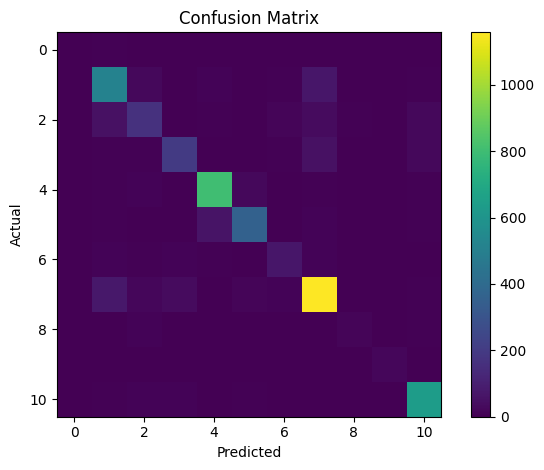

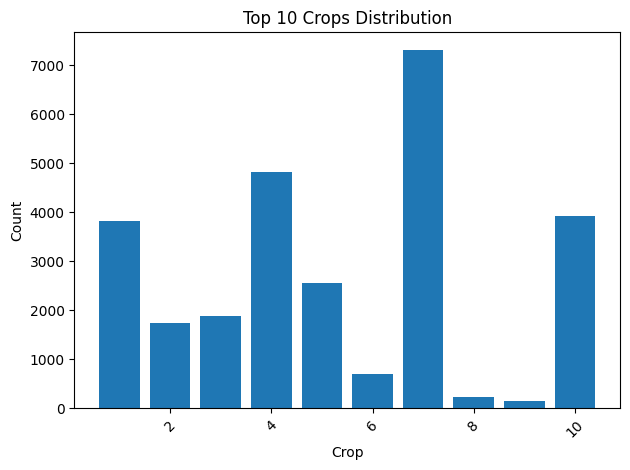


Feature Importance:

        Feature  Importance
5         Yield    0.956707
7  Market_Price    0.023054
4          Crop    0.007319
3        Season    0.005533
0         State    0.002721
6      Rainfall    0.002576
2          Year    0.001272
1      District    0.000818


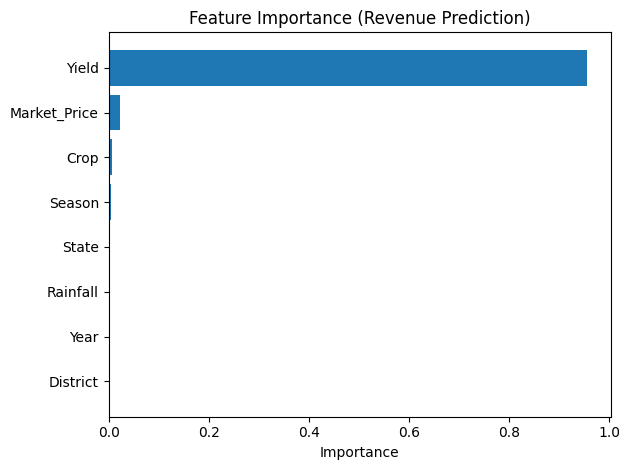

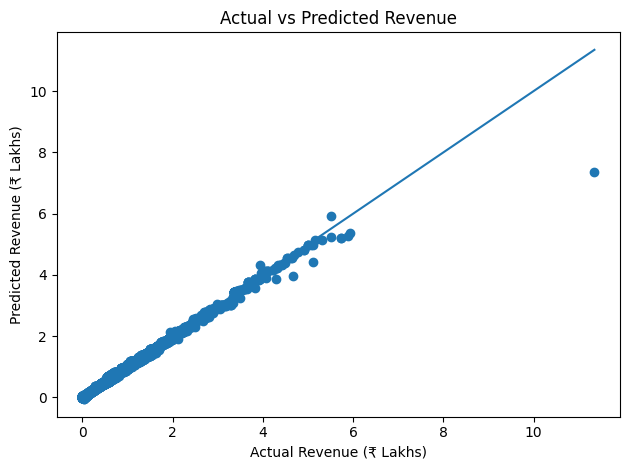

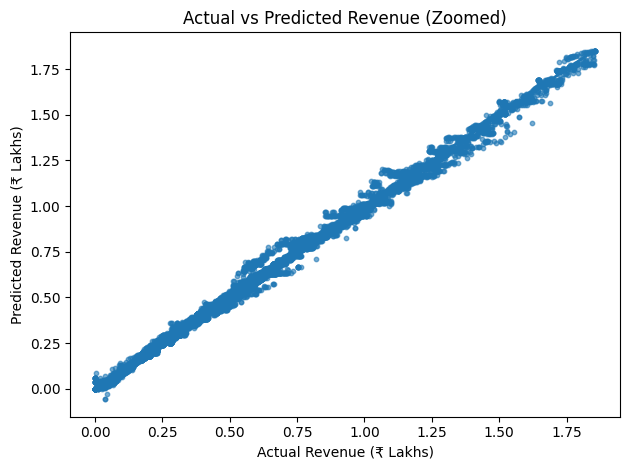

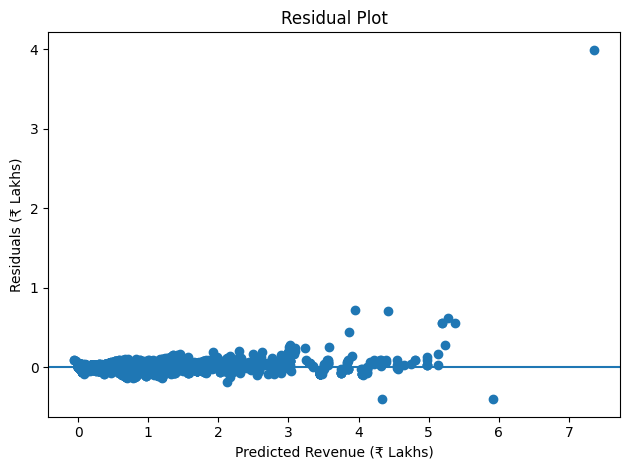

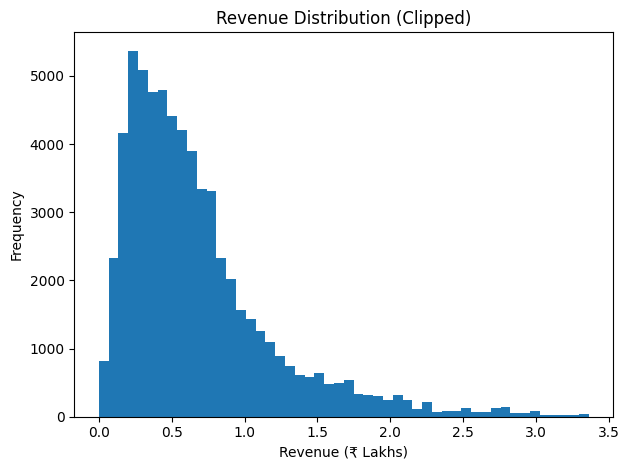

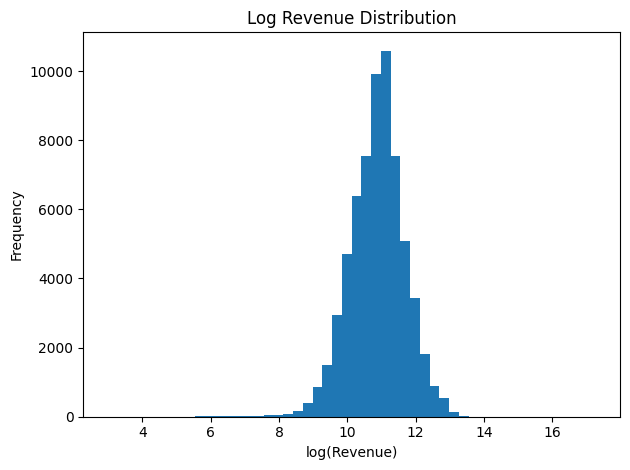

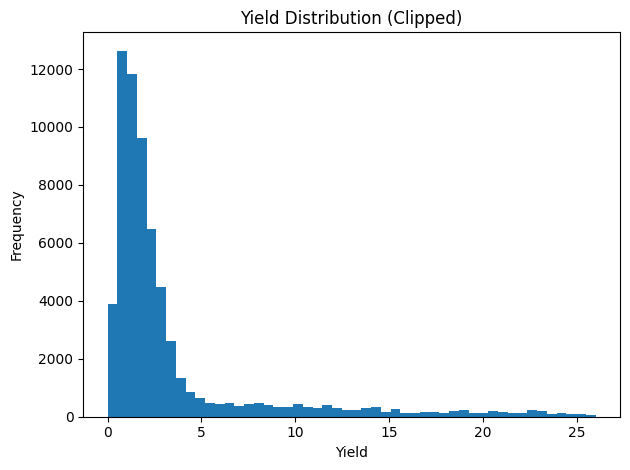

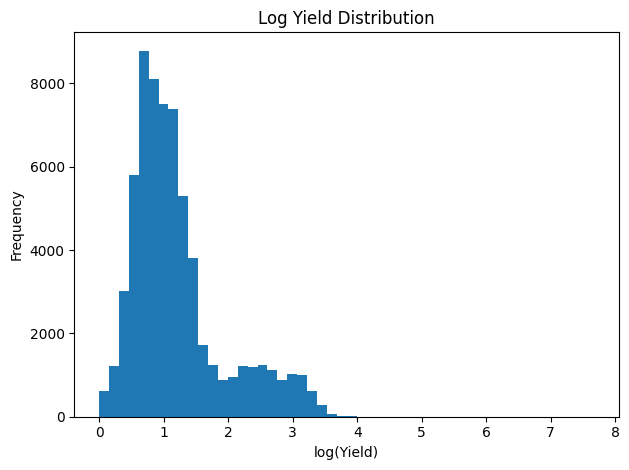

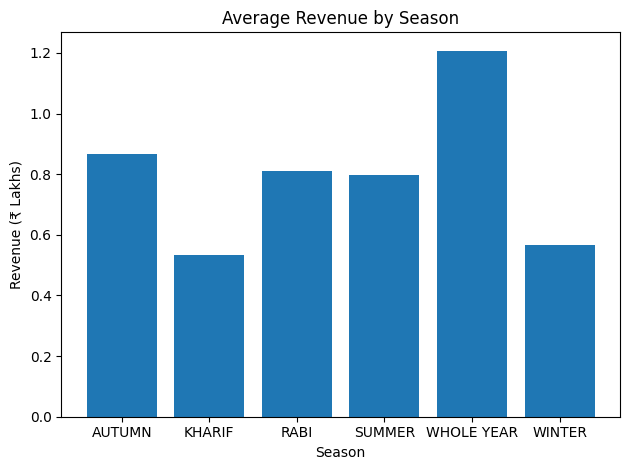


Sample Data Table:

                          State                  District   Crop  \
2   ANDAMAN AND NICOBAR ISLANDS                  NICOBARS   RICE   
12  ANDAMAN AND NICOBAR ISLANDS                  NICOBARS   RICE   
18  ANDAMAN AND NICOBAR ISLANDS                  NICOBARS   RICE   
27  ANDAMAN AND NICOBAR ISLANDS                  NICOBARS   RICE   
36  ANDAMAN AND NICOBAR ISLANDS                  NICOBARS   RICE   
45  ANDAMAN AND NICOBAR ISLANDS                  NICOBARS   RICE   
64  ANDAMAN AND NICOBAR ISLANDS                  NICOBARS   RICE   
71  ANDAMAN AND NICOBAR ISLANDS                  NICOBARS  MAIZE   
81  ANDAMAN AND NICOBAR ISLANDS  NORTH AND MIDDLE ANDAMAN   RICE   
92  ANDAMAN AND NICOBAR ISLANDS  NORTH AND MIDDLE ANDAMAN   RICE   

          Revenue  
2    96840.769608  
12  111223.493976  
18   83083.950000  
27   53359.542532  
36   42181.940782  
45  177563.784689  
64   87919.523810  
71   72836.980556  
81   90962.327257  
92   85599.400134  

Model Per

In [5]:
# =====================================================
# VISUALIZATIONS + TABLES (FINAL PERFECT VERSION)
# =====================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, r2_score

# =====================================================
# 1. CLASSIFICATION REPORT TABLE
# =====================================================
report = classification_report(y_test_c, clf.predict(X_test_c), output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("\nClassification Report:\n")
print(report_df)

report_df.to_csv("classification_report.csv")


# =====================================================
# 2. CONFUSION MATRIX
# =====================================================
cm = confusion_matrix(y_test_c, clf.predict(X_test_c))

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.tight_layout()
plt.show()


# =====================================================
# 3. TOP CROPS DISTRIBUTION
# =====================================================
crop_counts = best_crop["Crop"].value_counts().head(10)

plt.figure()
plt.bar(crop_counts.index, crop_counts.values)
plt.title("Top 10 Crops Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# =====================================================
# 4. FEATURE IMPORTANCE (REGRESSION)
# =====================================================
importances = reg.feature_importances_
features = X_reg.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n")
print(feat_df)

plt.figure()
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.title("Feature Importance (Revenue Prediction)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# =====================================================
# 5. ACTUAL VS PREDICTED (₹ LAKHS)
# =====================================================
y_pred = reg.predict(X_test_r)

y_actual_lakh = y_test_r / 1e5
y_pred_lakh = y_pred / 1e5

plt.figure()
plt.scatter(y_actual_lakh, y_pred_lakh)

plt.xlabel("Actual Revenue (₹ Lakhs)")
plt.ylabel("Predicted Revenue (₹ Lakhs)")
plt.title("Actual vs Predicted Revenue")

plt.plot([y_actual_lakh.min(), y_actual_lakh.max()],
         [y_actual_lakh.min(), y_actual_lakh.max()])

plt.tight_layout()
plt.show()


# =====================================================
# 6. ACTUAL VS PREDICTED (ZOOMED - BEST GRAPH)
# =====================================================
limit = np.percentile(y_actual_lakh, 95)
mask = y_actual_lakh < limit

plt.figure()

plt.scatter(
    y_actual_lakh[mask],
    y_pred_lakh[mask],
    s=10,          # 👈 smaller points
    alpha=0.6      # 👈 slight transparency
)

plt.xlabel("Actual Revenue (₹ Lakhs)")
plt.ylabel("Predicted Revenue (₹ Lakhs)")
plt.title("Actual vs Predicted Revenue (Zoomed)")

# diagonal line (make it thicker + visible)
plt.plot(
    [y_actual_lakh[mask].min(), y_actual_lakh[mask].max()],
    [y_actual_lakh[mask].min(), y_actual_lakh[mask].max()],
    linewidth=2
)

plt.tight_layout()
plt.show()


# =====================================================
# 7. RESIDUAL PLOT
# =====================================================
residuals = (y_test_r - y_pred) / 1e5

plt.figure()
plt.scatter(y_pred_lakh, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted Revenue (₹ Lakhs)")
plt.ylabel("Residuals (₹ Lakhs)")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()


# =====================================================
# 8. REVENUE DISTRIBUTION (CLIPPED)
# =====================================================
rev_lakh = data["Revenue"] / 1e5
rev_clip = rev_lakh[rev_lakh < rev_lakh.quantile(0.99)]

plt.figure()
plt.hist(rev_clip, bins=50)

plt.title("Revenue Distribution (Clipped)")
plt.xlabel("Revenue (₹ Lakhs)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# =====================================================
# 9. LOG REVENUE DISTRIBUTION (FIXED)
# =====================================================
log_data = np.log(data["Revenue"][data["Revenue"] > 0])

plt.figure()
plt.hist(log_data, bins=50)

plt.title("Log Revenue Distribution")
plt.xlabel("log(Revenue)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# =====================================================
# 10. YIELD DISTRIBUTION (CLIPPED)
# =====================================================
yield_clip = data["Yield"][data["Yield"] < data["Yield"].quantile(0.99)]

plt.figure()
plt.hist(yield_clip, bins=50)

plt.title("Yield Distribution (Clipped)")
plt.xlabel("Yield")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# =====================================================
# 11. LOG YIELD DISTRIBUTION
# =====================================================
plt.figure()
plt.hist(np.log1p(data["Yield"]), bins=50)

plt.title("Log Yield Distribution")
plt.xlabel("log(Yield)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# =====================================================
# 12. SEASONAL ANALYSIS
# =====================================================
season_avg = data.groupby("Season")["Revenue"].mean() / 1e5

plt.figure()
plt.bar(season_avg.index, season_avg.values)

plt.title("Average Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Revenue (₹ Lakhs)")

plt.tight_layout()
plt.show()


# =====================================================
# 13. SAMPLE DATA TABLE
# =====================================================
sample_output = data[["State", "District", "Crop", "Revenue"]].head(10)

print("\nSample Data Table:\n")
print(sample_output)

sample_output.to_csv("sample_output.csv", index=False)


# =====================================================
# 14. MODEL PERFORMANCE TABLE
# =====================================================
model_results = pd.DataFrame({
    "Model": ["Stacking Classifier", "Gradient Boosting Regressor"],
    "Metric": ["Accuracy", "R2 Score"],
    "Score": [
        accuracy_score(y_test_c, clf.predict(X_test_c)),
        r2_score(y_test_r, reg.predict(X_test_r))
    ]
})

print("\nModel Performance:\n")
print(model_results)

model_results.to_csv("model_results.csv", index=False)

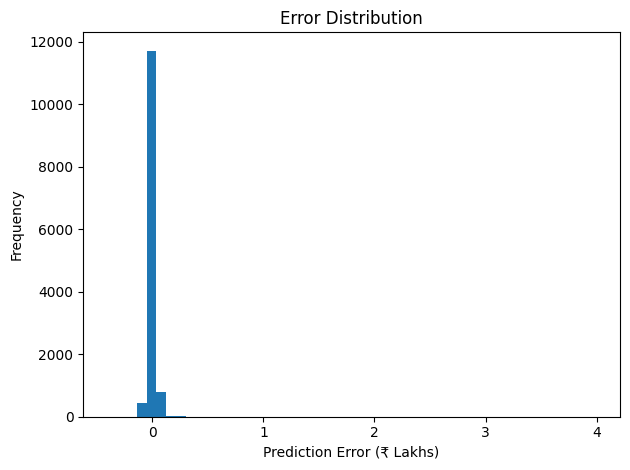

In [6]:
errors = (y_test_r - y_pred) / 1e5  # in lakhs

plt.figure()
plt.hist(errors, bins=50)

plt.title("Error Distribution")
plt.xlabel("Prediction Error (₹ Lakhs)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

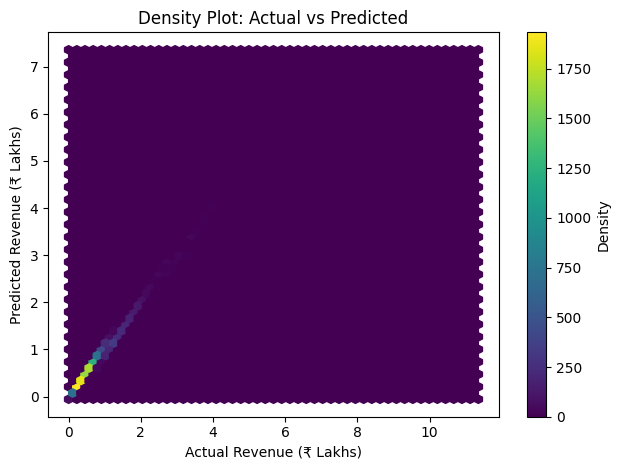

In [7]:
plt.figure()
plt.hexbin(y_actual_lakh, y_pred_lakh, gridsize=50)
plt.colorbar(label="Density")

plt.xlabel("Actual Revenue (₹ Lakhs)")
plt.ylabel("Predicted Revenue (₹ Lakhs)")
plt.title("Density Plot: Actual vs Predicted")

plt.tight_layout()
plt.show()

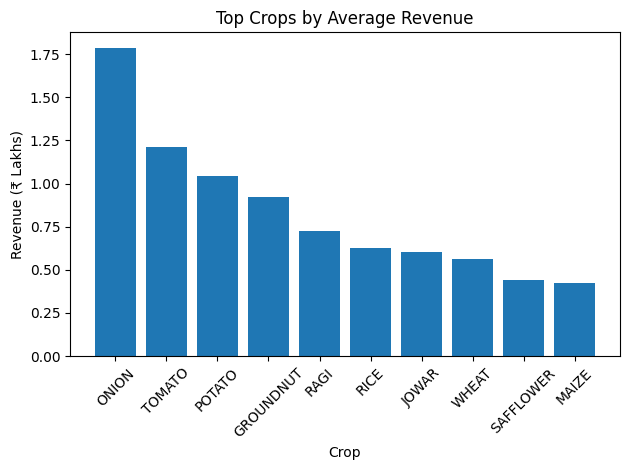

In [8]:
top_crops = data.groupby("Crop")["Revenue"].mean().sort_values(ascending=False).head(10)

plt.figure()
plt.bar(top_crops.index, top_crops.values / 1e5)

plt.title("Top Crops by Average Revenue")
plt.xlabel("Crop")
plt.ylabel("Revenue (₹ Lakhs)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

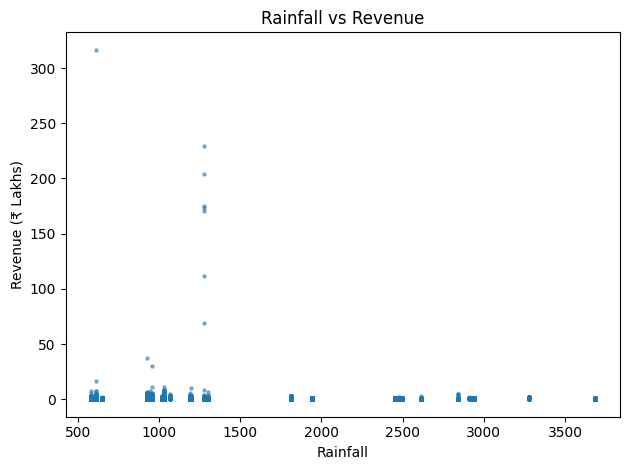

In [9]:
plt.figure()
plt.scatter(data["Rainfall"], data["Revenue"] / 1e5, s=5, alpha=0.5)

plt.title("Rainfall vs Revenue")
plt.xlabel("Rainfall")
plt.ylabel("Revenue (₹ Lakhs)")

plt.tight_layout()
plt.show()

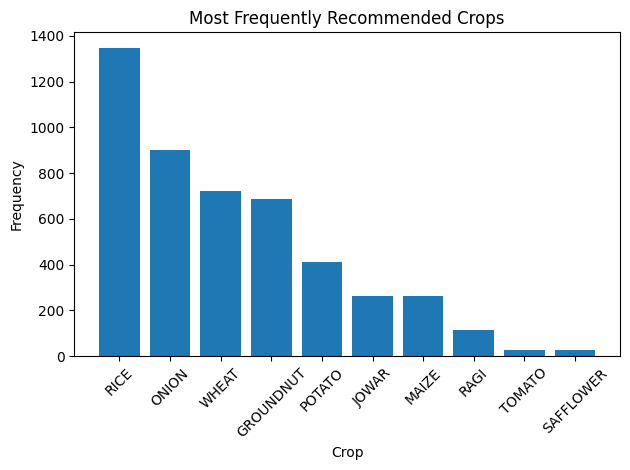

In [10]:
predicted_crops = clf.predict(X_test_c)

crop_names = le_crop.inverse_transform(predicted_crops)

crop_freq = pd.Series(crop_names).value_counts().head(10)

plt.figure()
plt.bar(crop_freq.index, crop_freq.values)

plt.title("Most Frequently Recommended Crops")
plt.xlabel("Crop")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

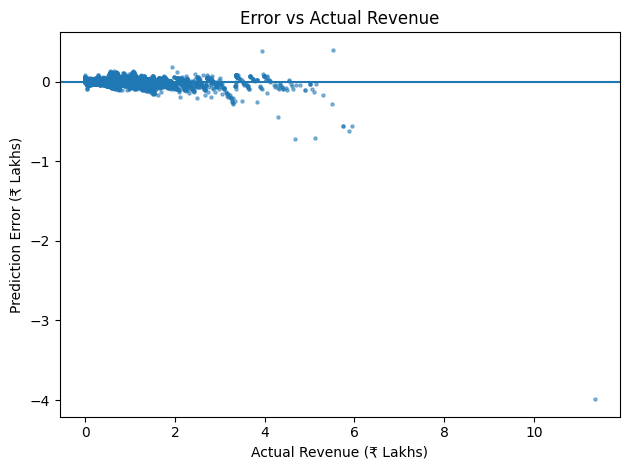

In [11]:
plt.figure()

errors = (y_pred - y_test_r) / 1e5   # in lakhs
actual_lakh = y_test_r / 1e5

plt.scatter(actual_lakh, errors, s=5, alpha=0.5)

plt.axhline(0)

plt.xlabel("Actual Revenue (₹ Lakhs)")
plt.ylabel("Prediction Error (₹ Lakhs)")
plt.title("Error vs Actual Revenue")

plt.tight_layout()
plt.show()

In [10]:
with open("districts.txt", "w") as f:
    for d in le_dist.classes_:
        f.write(d + "\n")